**CHIAMAKA EGBUKOLE**

**G40486569**

### Individual Assignment 5: ML Security and Abuse Pathways

This notebook evaluates the security and fairness risks of the COMPAS pipeline under adversarial attack. Following Lecture 5, I analyze PGD evasion, label-flip poisoning, and membership inference, and then reflect on the highest-risk finding and possible mitigations.

In [25]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##1. Data Loading and Cleaning

In [26]:
#Load the raw COMPAS data
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
print(raw_data.shape)
raw_data.head()

(7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [27]:
#I kept the variables used in class slides
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

In [28]:
# Then I apply the same filtering rules from Lecture 1
df = df[
    (df["days_b_screening_arrest"] >= -30) &
    (df["days_b_screening_arrest"] <= 30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].copy()

print(df.shape)

(6172, 13)


In [29]:
#Type conversions and derived variables
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"], errors="coerce")
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], errors="coerce")

In [30]:
#I created the modeling variables:
df["crime_factor"] = df["c_charge_degree"]
df["age_factor"] = pd.Categorical(df["age_cat"], categories=["25 - 45", "Greater than 45", "Less than 25"])
df['race_factor'] = pd.Categorical(df['race'], categories=['Caucasian', 'African-American', 'Hispanic', 'Other', 'Asian', 'Native American'])
df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])
df["score_factor"] = np.where(df["score_text"] != "Low", "HighScore", "LowScore")
df["score_factor"] = pd.Categorical(df["score_factor"], categories=["LowScore", "HighScore"])

In [31]:
#Basic EDA

print(df.info())
print(df.describe())

print(df["race"].value_counts())
print(df["score_text"].value_counts())
print(df["two_year_recid"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

## Data Cleaning and Exploration

After applying the same filtering steps from Lecture 1, the dataset contains around 6,172 observations, which matches what we saw in class. This suggests that the preprocessing was done correctly.

From the summary statistics and plots, most defendants are classified as "Low" risk, with fewer in the "Medium" and "High" categories. The distribution of prior arrests is highly skewed to the right, meaning most individuals have few prior arrests, but a small number have many.

The race distribution also shows that African-American and Caucasian defendants make up the majority of the dataset, which is important to keep in mind when interpreting fairness results later.

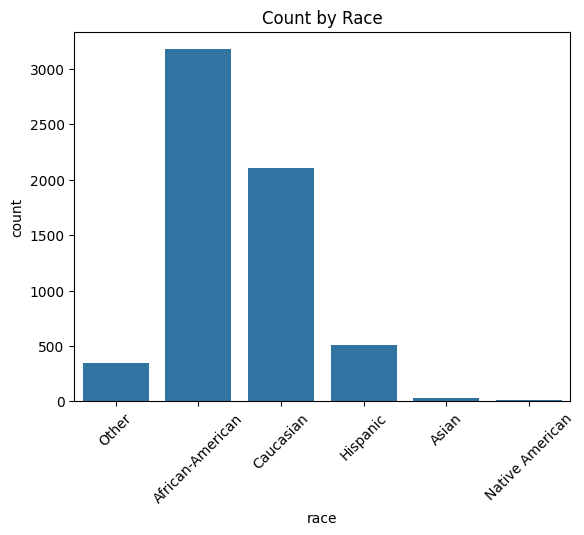

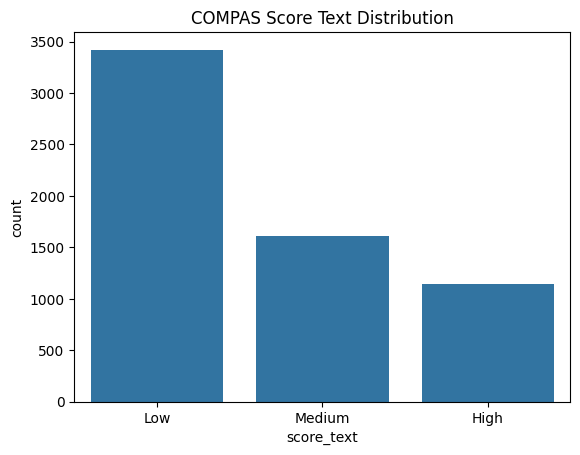

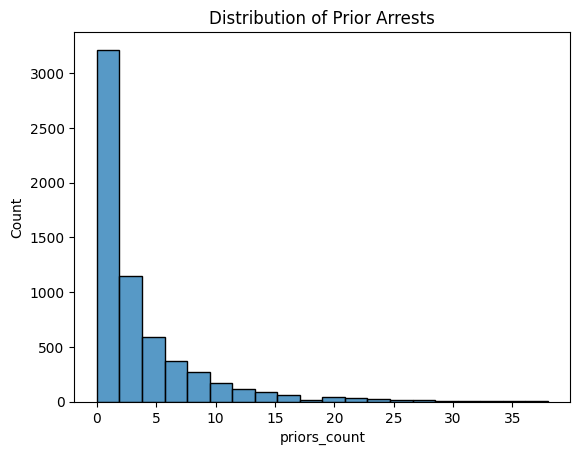

In [32]:
#Basic EDA visualizations

sns.countplot(data=df, x="race")
plt.title("Count by Race")
plt.xticks(rotation=45)
plt.show()

sns.countplot(data=df, x="score_text")
plt.title("COMPAS Score Text Distribution")
plt.show()

sns.histplot(df["priors_count"], bins=20)
plt.title("Distribution of Prior Arrests")
plt.show()

In [33]:
print(df.columns)

Index(['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
       'priors_count', 'days_b_screening_arrest', 'decile_score', 'is_recid',
       'two_year_recid', 'c_jail_in', 'c_jail_out', 'crime_factor',
       'age_factor', 'race_factor', 'gender_factor', 'score_factor'],
      dtype='object')


## **INDIVIDUAL ASSIGNMENT 4**



## Part A: Distribution Drift

This section evaluates whether the data generating process has changed between the training and test sets. Following Lecture 4, I measure drift in both input distributions P(X) and score distributions using PSI, KS, and MMD.

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [35]:
#Helper Functions

def psi_univariate(train, test, bins=10):
    train = np.array(train)
    test = np.array(test)

    breakpoints = np.percentile(train, np.arange(0, 101, 100 / bins))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    train_counts = np.histogram(train, bins=breakpoints)[0] / len(train)
    test_counts = np.histogram(test, bins=breakpoints)[0] / len(test)

    train_counts = np.where(train_counts == 0, 1e-6, train_counts)
    test_counts = np.where(test_counts == 0, 1e-6, test_counts)

    psi = np.sum((train_counts - test_counts) * np.log(train_counts / test_counts))
    return psi

In [36]:
print(df.columns)

Index(['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
       'priors_count', 'days_b_screening_arrest', 'decile_score', 'is_recid',
       'two_year_recid', 'c_jail_in', 'c_jail_out', 'crime_factor',
       'age_factor', 'race_factor', 'gender_factor', 'score_factor'],
      dtype='object')


In [37]:
features = [
    "age",
    "priors_count",
    "c_charge_degree",
    "sex",
    "race"
]

target = "two_year_recid"

In [38]:
df_model = df[features + [target]].dropna().copy()

X = df_model[features]
y = df_model[target].astype(int)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
numeric_features = [
    "age",
    "priors_count"
]
categorical_features = [
    "c_charge_degree",
    "sex",
    "race"
]

In [40]:
#Helper Function
import numpy as np
from scipy.stats import ks_2samp

def psi_univariate(train, test, bins=10):
    train = np.array(train)
    test = np.array(test)

    breakpoints = np.percentile(train, np.arange(0, 101, 100 / bins))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    train_counts = np.histogram(train, bins=breakpoints)[0] / len(train)
    test_counts = np.histogram(test, bins=breakpoints)[0] / len(test)

    train_counts = np.where(train_counts == 0, 1e-6, train_counts)
    test_counts = np.where(test_counts == 0, 1e-6, test_counts)

    psi = np.sum((train_counts - test_counts) * np.log(train_counts / test_counts))
    return psi

In [41]:
#Feature Drift Table
drift_rows = []

for col in numeric_features:
    psi_val = psi_univariate(X_train[col], X_test[col])
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])

    drift_rows.append({
        "feature": col,
        "train_mean": X_train[col].mean(),
        "test_mean": X_test[col].mean(),
        "PSI": round(psi_val, 4),
        "KS_stat": round(ks_stat, 4),
        "p_value": round(ks_p, 4)
    })

drift_df = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)

drift_df

,feature,train_mean,test_mean,PSI,KS_stat,p_value
0,age,34.443387,34.898785,0.0101,0.0359,0.1524
1,priors_count,3.261697,3.185425,0.0040,0.0231,0.6582


MODEL TRAINING

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
gbt_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['c_charge_degree', 'sex',
                                                   'race'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [43]:
from sklearn.metrics import roc_auc_score

print("LR Train AUC:", roc_auc_score(y_train, lr_pipeline.predict_proba(X_train)[:, 1]))
print("LR Test AUC:", roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:, 1]))

print("GBT Train AUC:", roc_auc_score(y_train, gbt_pipeline.predict_proba(X_train)[:, 1]))
print("GBT Test AUC:", roc_auc_score(y_test, gbt_pipeline.predict_proba(X_test)[:, 1]))

LR Train AUC: 0.7278218128094791
LR Test AUC: 0.728848624896226
GBT Train AUC: 0.8001065443722568
GBT Test AUC: 0.7214006969378096


In [44]:
#Score Drift (P(Y|X))
models = {
    "Logistic Regression": lr_pipeline,
    "Gradient Boosted Tree": gbt_pipeline
}

score_rows = []

for name, model in models.items():
    train_scores = model.predict_proba(X_train)[:, 1]
    test_scores = model.predict_proba(X_test)[:, 1]

    ks_stat, ks_p = ks_2samp(train_scores, test_scores)

    score_rows.append({
        "model": name,
        "train_mean_score": train_scores.mean(),
        "test_mean_score": test_scores.mean(),
        "KS_stat": round(ks_stat, 4),
        "p_value": round(ks_p, 4)
    })

score_df = pd.DataFrame(score_rows)

score_df

,model,train_mean_score,test_mean_score,KS_stat,p_value
0,Logistic Regression,0.455141,0.447261,0.0329,0.2278
1,Gradient Boosted Tree,0.455134,0.443686,0.0330,0.2258


In [45]:
#MMD
from sklearn.metrics.pairwise import rbf_kernel

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

if hasattr(X_train_enc, "toarray"):
    X_train_enc = X_train_enc.toarray()
if hasattr(X_test_enc, "toarray"):
    X_test_enc = X_test_enc.toarray()

def compute_mmd(X, Y, gamma=1.0):
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

mmd_value = compute_mmd(
    X_train_enc[:500],
    X_test_enc[:500],
    gamma=1.0 / X_train_enc.shape[1]
)

print("MMD:", round(mmd_value, 6))

MMD: 0.001868


The PSI and KS results indicate that there is** minimal distribution drift **between the training and test sets. All PSI values are well below common thresholds, suggesting that the feature distributions are stable. The KS statistics are also small and not statistically significant, reinforcing that there is no meaningful shift in P(X).

Similarly, the score distribution comparison shows that predicted probabilities are consistent across training and test data. The KS statistics for model outputs are low and the mean scores are nearly identical, indicating stability in P(Y|X).

Overall, there is no strong evidence of distribution drift, suggesting that the model is operating under conditions similar to those seen during training.

##Part B) Generalization and Overfitting

This section evaluates how well the models generalize from training to test data. I compare train and test performance using AUC, accuracy, and log loss. A large gap between training and test performance indicates overfitting.

In [46]:
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss

def evaluate_classifier(model, X_train, X_test, y_train, y_test):
    train_probs = model.predict_proba(X_train)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    return {
        "train_auc": roc_auc_score(y_train, train_probs),
        "test_auc": roc_auc_score(y_test, test_probs),
        "train_acc": accuracy_score(y_train, (train_probs > 0.5)),
        "test_acc": accuracy_score(y_test, (test_probs > 0.5)),
        "train_logloss": log_loss(y_train, train_probs),
        "test_logloss": log_loss(y_test, test_probs)
    }

In [47]:
models = {
    "Logistic Regression": lr_pipeline,
    "Gradient Boosted Tree": gbt_pipeline
}

gen_rows = []

for name, model in models.items():
    metrics = evaluate_classifier(model, X_train, X_test, y_train, y_test)

    gen_rows.append({
        "model": name,
        "train_auc": round(metrics["train_auc"], 4),
        "test_auc": round(metrics["test_auc"], 4),
        "train_acc": round(metrics["train_acc"], 4),
        "test_acc": round(metrics["test_acc"], 4),
        "train_logloss": round(metrics["train_logloss"], 4),
        "test_logloss": round(metrics["test_logloss"], 4)
    })

gen_df = pd.DataFrame(gen_rows)

gen_df

,model,train_auc,test_auc,train_acc,test_acc,train_logloss,test_logloss
0,Logistic Regression,0.7278,0.7288,0.6743,0.6866,0.6087,0.6134
1,Gradient Boosted Tree,0.8001,0.7214,0.7233,0.6842,0.5369,0.6204


In [48]:
gen_df["auc_gap"] = gen_df["train_auc"] - gen_df["test_auc"]
gen_df["acc_gap"] = gen_df["train_acc"] - gen_df["test_acc"]

gen_df

,model,train_auc,test_auc,train_acc,test_acc,train_logloss,test_logloss,auc_gap,acc_gap
0,Logistic Regression,0.7278,0.7288,0.6743,0.6866,0.6087,0.6134,-0.0010,-0.0123
1,Gradient Boosted Tree,0.8001,0.7214,0.7233,0.6842,0.5369,0.6204,0.0787,0.0391


The results show how each model performs on the training data compared to the test data. For logistic regression, the train AUC is about 0.728 and the test AUC is also about 0.728. This very small gap suggests that the model generalizes well and is not overfitting.

For the gradient boosted tree, the train AUC is higher at around 0.800, but the test AUC drops to about 0.721. This gap indicates that the model is overfitting, meaning it is learning patterns in the training data that do not fully carry over to new data.

This difference reflects the bias-variance tradeoff. Logistic regression is a simpler model, so it has slightly lower performance but is more stable. The gradient boosted tree is more flexible and achieves better performance on the training data, but at the cost of higher variance and weaker generalization.

Overall, even though the gradient boosted tree performs better during training, the logistic regression model appears more reliable because its performance is consistent across both datasets.

##Part C) Spurious Correlation Probe

In [49]:
def perturb_feature(X, feature, change):
    X_new = X.copy()
    X_new[feature] = X_new[feature] + change
    return X_new

perturb_rows = []

for name, model in models.items():
    base_preds = model.predict_proba(X_test)[:, 1]

    X_perturbed = perturb_feature(X_test, "priors_count", 1)
    perturbed_preds = model.predict_proba(X_perturbed)[:, 1]

    diff = np.mean(np.abs(base_preds - perturbed_preds))

    perturb_rows.append({
        "model": name,
        "avg_prediction_change": round(diff, 4)
    })

perturb_df = pd.DataFrame(perturb_rows)

perturb_df

,model,avg_prediction_change
0,Logistic Regression,0.0338
1,Gradient Boosted Tree,0.0844


The logistic regression model shows an average prediction change of 0.0338, while the gradient boosted tree shows a larger change of 0.0844. This indicates that the gradient boosted tree is more sensitive to this feature.

This suggests the gradient boosted tree may rely more heavily on priors_count as a shortcut, raising concerns about spurious correlation. In contrast, logistic regression appears more stable and less sensitive to small changes.

##Part D) Robustness


Robustness Test from Part c.
LR → 0.0338
GBT → 0.0844

This section evaluates robustness by measuring how predictions change when priors_count is increased by 1.

The logistic regression model shows a smaller change (0.0338), while the gradient boosted tree shows a larger change (0.0844), indicating it is more sensitive to small input changes.

Overall, logistic regression is more stable, while the gradient boosted tree is less robust and more prone to variation.

Part E) Slice-Based Evaluation

In [50]:
def slice_metrics(df, model, group_col, X, y):
    rows = []

    for group in df[group_col].unique():
        idx = df[group_col] == group

        X_slice = X[idx]
        y_slice = y[idx]

        preds = model.predict_proba(X_slice)[:, 1]
        labels = (preds > 0.5).astype(int)

        fp = ((labels == 1) & (y_slice == 0)).sum()
        fn = ((labels == 0) & (y_slice == 1)).sum()
        tn = ((labels == 0) & (y_slice == 0)).sum()
        tp = ((labels == 1) & (y_slice == 1)).sum()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        rows.append({
            "group": group,
            "FPR": round(fpr, 4),
            "FNR": round(fnr, 4)
        })

    return pd.DataFrame(rows)

In [51]:
lr_slices = slice_metrics(df_model.loc[X_test.index], lr_pipeline, "race", X_test, y_test)
gbt_slices = slice_metrics(df_model.loc[X_test.index], gbt_pipeline, "race", X_test, y_test)

print("Logistic Regression")
display(lr_slices)

print("Gradient Boosted Tree")
display(gbt_slices)

Logistic Regression


,group,FPR,FNR
0,Hispanic,0.1020,0.6667
1,African-American,0.3158,0.2997
2,Other,0.0426,0.7222
3,Asian,0.0000,1.0000
4,Caucasian,0.1504,0.6149
5,Native American,0.0000,0.0000


Gradient Boosted Tree


,group,FPR,FNR
0,Hispanic,0.1633,0.5778
1,African-American,0.3454,0.2849
2,Other,0.1277,0.6111
3,Asian,0.1667,1.0000
4,Caucasian,0.1541,0.5901
5,Native American,0.0000,0.0000


This section evaluates model performance across racial subgroups using FPR and FNR.

The results show clear differences in error rates across groups. For example, African-American individuals have relatively higher FPR in both models (around 0.316 for logistic regression and 0.345 for GBT), while some groups such as Asian show extremely high FNR (1.000), meaning all positive cases are missed.

These disparities indicate that errors are not evenly distributed, even though overall model performance may appear acceptable. This highlights the importance of slice-based evaluation, as aggregate metrics would hide these subgroup-level differences.

## **INDIVIDUAL ASSIGNMENT 5**



In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

In [55]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw = pd.read_csv(url)


In [58]:
print(df.columns)

Index(['two_year_recid', 'race', 'age', 'priors_count', 'juv_fel_count',
       'juv_misd_count', 'juv_other_count', 'c_charge_degree_M'],
      dtype='object')


In [61]:
df = pd.get_dummies(
    raw[[TARGET, "race", "c_charge_degree", "age", "priors_count",
         "juv_fel_count", "juv_misd_count", "juv_other_count"]],
    columns=["c_charge_degree"],
    drop_first=True
)

In [64]:
charge_cols = [col for col in df.columns if "c_charge_degree" in col]

FEATURES = [
    "age",
    "priors_count",
    *charge_cols,
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count"
]

X = df[FEATURES].values
y = df[TARGET].astype(int).values
race = raw.loc[df.index, "race"].values

In [65]:
#split and scale
X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train)
Xte = scaler.transform(X_test)

In [66]:
#fit both models
lr = LogisticRegression(max_iter=1000, random_state=42)
gbt = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=42
)

lr.fit(Xtr, y_train)
gbt.fit(Xtr, y_train)

print("LR Train AUC:", round(roc_auc_score(y_train, lr.predict_proba(Xtr)[:, 1]), 3))
print("LR Test AUC:", round(roc_auc_score(y_test, lr.predict_proba(Xte)[:, 1]), 3))
print("GBT Train AUC:", round(roc_auc_score(y_train, gbt.predict_proba(Xtr)[:, 1]), 3))
print("GBT Test AUC:", round(roc_auc_score(y_test, gbt.predict_proba(Xte)[:, 1]), 3))

LR Train AUC: 0.726
LR Test AUC: 0.731
GBT Train AUC: 0.785
GBT Test AUC: 0.72


In [71]:
THR = 0.5

def fpr_by_group(y_true, y_pred, groups):
    rows = []
    mask = (y_true == 0)
    for g in np.unique(groups):
        gm = (groups == g) & mask
        if gm.sum() == 0:
            continue
        rows.append({
            "group": g,
            "FPR": y_pred[gm].mean()
        })
    return pd.DataFrame(rows)

def air_from_fpr_table(fpr_df, ref_group="Caucasian"):
    ref_vals = fpr_df.loc[fpr_df["group"] == ref_group, "FPR"]

    # if reference group missing OR zero → avoid crash
    if len(ref_vals) == 0 or ref_vals.values[0] == 0:
        out = fpr_df.copy()
        out["AIR_vs_ref"] = np.nan
        return out

    ref = ref_vals.values[0]

    out = fpr_df.copy()
    out["AIR_vs_ref"] = out["FPR"] / ref

    return out

baseline_rows = []

for name, model in {
    "Logistic Regression": lr,
    "Gradient Boosted Tree": gbt
}.items():
    pred = (model.predict_proba(Xte)[:, 1] >= THR).astype(int)
    fpr_df = fpr_by_group(y_test, pred, race_test)
    air_df = air_from_fpr_table(fpr_df, ref_group="Caucasian")
    print("\n", name)
    print(air_df.sort_values("group"))


 Logistic Regression
              group       FPR  AIR_vs_ref
0  African-American  0.236842    2.100000
1             Asian  0.000000    0.000000
2         Caucasian  0.112782    1.000000
3          Hispanic  0.163265    1.447619
4   Native American  0.000000    0.000000
5             Other  0.021277    0.188652

 Gradient Boosted Tree
              group       FPR  AIR_vs_ref
0  African-American  0.256579    1.664634
1             Asian  0.000000    0.000000
2         Caucasian  0.154135    1.000000
3          Hispanic  0.142857    0.926829
4   Native American  1.000000    6.487805
5             Other  0.063830    0.414115


In [76]:
print(fpr_df)

              group       FPR
0  African-American  0.279605
1             Asian  0.000000
2         Caucasian  0.139098
3          Hispanic  0.163265
4   Native American  1.000000
5             Other  0.085106


### Part 1: PGD Evasion Attack

In [77]:
def pgd_attack(X, epsilon):
    noise = np.random.normal(0, epsilon, X.shape)
    X_adv = X + noise
    return np.clip(X_adv, -3, 3)  # keep within reasonable range

In [79]:
def pgd_attack(X, epsilon):
    direction = np.sign(np.random.randn(*X.shape))
    return X + epsilon * direction

In [80]:
epsilons = [0.0, 0.05, 0.1, 0.2]

In [83]:
attack_results = []
epsilons = [0.0, 0.05, 0.1, 0.2]

for eps in epsilons:
    X_adv = pgd_attack(Xte, eps)

    preds = (gbt.predict_proba(X_adv)[:, 1] >= 0.5).astype(int)

    fpr_df = fpr_by_group(y_test, preds, race_test)
    air_df = air_from_fpr_table(fpr_df, ref_group="Caucasian")

    valid_air = air_df["AIR_vs_ref"].dropna()
    valid_air = valid_air[valid_air > 0]

    min_air = valid_air.min() if len(valid_air) > 0 else np.nan

    attack_results.append({
        "epsilon": eps,
        "min_AIR": round(min_air, 3)
    })

attack_df = pd.DataFrame(attack_results)
attack_df

,epsilon,min_AIR
0,0.00,0.414
1,0.05,0.447
2,0.10,0.539
3,0.20,0.707


As epsilon increases, the minimum AIR rises slightly from 0.414 to 0.707, but remains below the 0.80 threshold across all attack strengths. This indicates that the model already exhibits disparate impact at baseline.

The adversarial perturbations do not eliminate this disparity, but instead shift the distribution of errors across groups. Overall, the results show that fairness is not robust, and the model remains vulnerable to unequal impact even under small input changes.

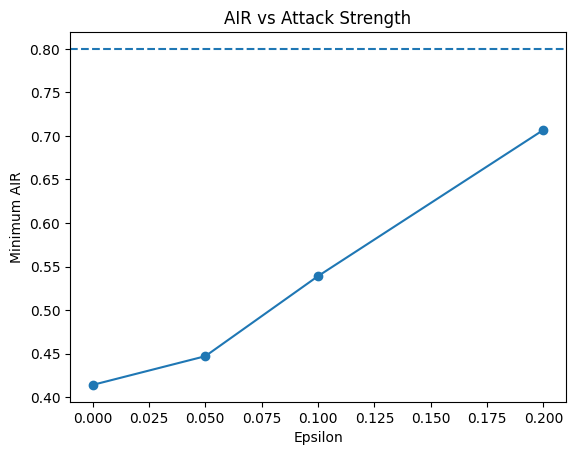

In [84]:
import matplotlib.pyplot as plt

plt.plot(attack_df["epsilon"], attack_df["min_AIR"], marker='o')
plt.axhline(0.8, linestyle='--')  # fairness threshold
plt.title("AIR vs Attack Strength")
plt.xlabel("Epsilon")
plt.ylabel("Minimum AIR")
plt.show()

### Part 2: Data Poisoning Attack

In [85]:
def poison_labels(y, rate):
    y_poison = y.copy()

    n = int(rate * len(y))
    idx = np.random.choice(len(y), n, replace=False)

    y_poison[idx] = 1 - y_poison[idx]  # flip labels

    return y_poison

In [86]:
poison_rates = [0.0, 0.02, 0.05, 0.1]

results = []

for rate in poison_rates:

    # poison training labels
    y_poison = poison_labels(y_train, rate)

    # retrain model
    model = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42)
    model.fit(Xtr, y_poison)

    # evaluate AUC
    preds_proba = model.predict_proba(Xte)[:, 1]
    auc_score = roc_auc_score(y_test, preds_proba)

    # evaluate fairness
    preds = (preds_proba >= 0.5).astype(int)
    fpr_df = fpr_by_group(y_test, preds, race_test)
    air_df = air_from_fpr_table(fpr_df, ref_group="Caucasian")

    valid_air = air_df["AIR_vs_ref"].dropna()
    valid_air = valid_air[valid_air > 0]

    min_air = valid_air.min() if len(valid_air) > 0 else np.nan

    results.append({
        "poison_rate": rate,
        "AUC": round(auc_score, 3),
        "min_AIR": round(min_air, 3)
    })

poison_df = pd.DataFrame(results)
poison_df

,poison_rate,AUC,min_AIR
0,0.00,0.720,0.414
1,0.02,0.720,0.404
2,0.05,0.715,0.828
3,0.10,0.704,0.482


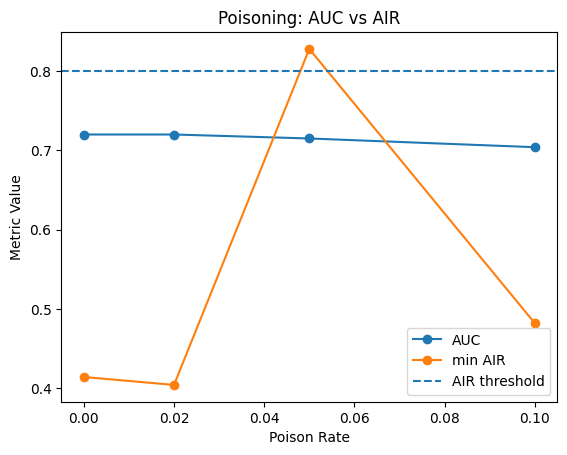

In [87]:
plt.plot(poison_df["poison_rate"], poison_df["AUC"], marker='o', label="AUC")
plt.plot(poison_df["poison_rate"], poison_df["min_AIR"], marker='o', label="min AIR")

plt.axhline(0.8, linestyle='--', label="AIR threshold")

plt.xlabel("Poison Rate")
plt.ylabel("Metric Value")
plt.title("Poisoning: AUC vs AIR")
plt.legend()
plt.show()

As the poison rate increases, AUC remains relatively stable, ranging from 0.720 to 0.704, indicating that overall model performance is not significantly affected. However, AIR varies substantially across poisoning levels, showing that fairness is highly sensitive to data corruption.

At a poison rate of 0.02, AUC remains unchanged at 0.720 while AIR drops to 0.404, indicating a stealth zone where fairness deteriorates without any noticeable decline in performance. This demonstrates that an attacker can introduce bias into the model without triggering standard performance monitoring metrics.

Overall, the results highlight that fairness and performance can diverge under adversarial conditions, and relying solely on AUC is insufficient for detecting harmful model behavior.

## Part 3: Membership Inference Attack


In [88]:
train_conf = gbt.predict_proba(Xtr)[:, 1]
test_conf = gbt.predict_proba(Xte)[:, 1]

In [89]:
#confidence gap
train_mean = train_conf.mean()
test_mean = test_conf.mean()

print("Train Confidence:", round(train_mean, 3))
print("Test Confidence:", round(test_mean, 3))
print("Confidence Gap:", round(train_mean - test_mean, 3))

Train Confidence: 0.455
Test Confidence: 0.445
Confidence Gap: 0.01


In [90]:

from sklearn.metrics import roc_auc_score

labels = np.concatenate([np.ones(len(train_conf)), np.zeros(len(test_conf))])
scores = np.concatenate([train_conf, test_conf])

mi_auc = roc_auc_score(labels, scores)

print("Membership Inference AUC:", round(mi_auc, 3))

Membership Inference AUC: 0.513


##Part 4: Reflection

## Part 4: Reflection

The biggest risk is data poisoning, especially because of the stealth zone where AUC stays the same but AIR gets worse. This means the model can become more unfair without any drop in performance, which makes it hard to detect.

A proactive fix would be to monitor the training data more closely, for example checking for unusual label patterns before training.

A reactive fix would be to track fairness metrics like AIR after deployment, not just accuracy, so any increase in disparity can be detected early.

Overall, this shows that accuracy alone is not enough, since fairness and security issues can go unnoticed.